# Import libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme()

# encode
from sklearn.preprocessing import LabelEncoder

# machine learning
from sklearn.ensemble import RandomForestClassifier

# datetime
from datetime import datetime

# xử lý chuỗi
import re

# Setting to make numbers easier to read on display
pd.options.display.float_format = '{:20.2f}'.format

# Show all columns on output
pd.set_option('display.max_columns', 999)

In [74]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Viewing data

In [75]:
# load dataset
file_path = "/content/drive/MyDrive/0003. FTU SUBJECTS/010. PHÂN TÍCH DỮ LIỆU/04. CUSTOMER SEGMENTATION PROJECT/01. MATERIAL/02. DATASET GỐC/Raw_data.xlsx - NewCustomerList.csv"
df = pd.read_csv(file_path)

In [76]:
display(df.head())

,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Rank,Value
0,Chickie,Brister,Male,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,"0,52","0,65","0,8125","0,690625",1,1,"1,71875"
1,Morly,Genery,Male,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,"0,41","0,41","0,5125","0,435625",1,1,"1,71875"
2,Ardelis,Forrester,Female,10,1974-08-28,Senior Cost Accountant,Financial Services,Affluent Customer,N,No,10,5 Colorado Crossing,3505,VIC,Australia,5,"0,69","0,69","0,69","0,69",1,1,"1,71875"
3,Lucine,Stutt,Female,64,1979-01-28,Account Representative III,Manufacturing,Affluent Customer,N,Yes,5,207 Annamark Plaza,4814,QLD,Australia,1,"0,47","0,5875","0,5875","0,5875",4,4,"1,703125"
4,Melinda,Hadlee,Female,34,1965-09-21,Financial Analyst,Financial Services,Affluent Customer,N,No,19,115 Montana Place,2093,NSW,Australia,9,"0,89","0,89","1,1125","1,1125",4,4,"1,703125"


# Inspect Dataset

---

## Infomation

In [77]:
# Hiển thị thông tin cơ bản về dữ liệu
print("Thông tin tổng quan về dataset:")
print(df.info())

Thông tin tổng quan về dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   first_name                           1000 non-null   object
 1   last_name                            971 non-null    object
 2   gender                               1000 non-null   object
 3   past_3_years_bike_related_purchases  1000 non-null   int64 
 4   DOB                                  983 non-null    object
 5   job_title                            894 non-null    object
 6   job_industry_category                835 non-null    object
 7   wealth_segment                       1000 non-null   object
 8   deceased_indicator                   1000 non-null   object
 9   owns_car                             1000 non-null   object
 10  tenure                               1000 non-null   int64 
 11  address     

---
---

### Mô tả ngắn gọn thông tin dữ liệu

Dữ liệu chứa thông tin về khách hàng tiềm năng của một công ty, với **1000 bản ghi** và **23 cột**. Dưới đây là mô tả chi tiết từng cột:

| Tên cột                              | Mô tả                                      | Số giá trị không null | Kiểu dữ liệu |
|--------------------------------------|--------------------------------------------|-----------------------|--------------|
| `first_name`                         | Tên của khách hàng                         | 1000                  | `object`     |
| `last_name`                          | Họ của khách hàng                          | 971                   | `object`     |
| `gender`                             | Giới tính của khách hàng                   | 1000                  | `object`     |
| `past_3_years_bike_related_purchases`| Những sản phẩm mua liên quan đến xe đạp trong 3 năm qua (Pedal, bánh xe, tăm xe, ...) | 1000              | `int64`      |
| `DOB`                                | Ngày sinh của khách hàng                   | 983                   | `object`     |
| `job_title`                          | Chức danh công việc                        | 894                   | `object`     |
| `job_industry_category`              | Ngành nghề công việc                       | 835                   | `object`     |
| `wealth_segment`                     | Phân khúc tài sản của khách hàng           | 1000                  | `object`     |
| `deceased_indicator`                 | Chỉ số cho biết khách hàng đã qua đời hay chưa | 1000               | `object`     |
| `owns_car`                           | Khách hàng có sở hữu xe hơi hay không      | 1000                  | `object`     |
| `tenure`                             | Số năm đi làm                | 1000                  | `float64`    |
| `address`                            | Địa chỉ của khách hàng                     | 1000                  | `object`     |
| `postcode`                           | Mã bưu chính                               | 1000                  | `int64`      |
| `state`                              | Bang/Tỉnh của khách hàng                   | 1000                  | `object`     |
| `country`                            | Quốc gia của khách hàng                    | 1000                  | `object`     |
| `property_valuation`                 | Giá trị tài sản cá nhân                             | 1000                  | `object`     |
| `Unnamed: 16`                        | Cột không liên quan (không rõ ý nghĩa)      | 1000                  | `object`     |
| `Unnamed: 17`                        | Cột không liên quan (không rõ ý nghĩa)      | 1000                  | `object`     |
| `Unnamed: 18`                        | Cột không liên quan (không rõ ý nghĩa)      | 1000                  | `object`     |
| `Unnamed: 19`                        | Cột không liên quan (không rõ ý nghĩa)      | 1000                  | `object`     |
| `Unnamed: 20`                        | Cột không liên quan (không rõ ý nghĩa)      | 1000                  | `int64`      |
| `Rank`                               | Xếp hạng                                   | 1000                  | `int64`      |
| `Value`                              | Giá trị mua hàng từ công ty                                 | 1000                  | `object`     |

---

## Tổng quan về kiểu dữ liệu
- **18 cột kiểu `object`**: Bao gồm các cột như tên, giới tính, địa chỉ, ngành nghề, và các cột không liên quan.
- **5 cột kiểu `int64/float64`**: Bao gồm các cột số như `past_3_years_bike_related_purchases`, `postcode`, `tenure`, `Unnamed: 20`, và `Rank`.

---

## Describe

In [78]:
# Numerical
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
past_3_years_bike_related_purchases,1000.00,49.84,27.80,0.00,26.75,51.00,72.00,99.00
tenure,1000.00,11.39,5.04,0.00,7.00,11.00,15.00,22.00
postcode,1000.00,3019.23,848.90,2000.00,2209.00,2800.00,3845.50,4879.00
Unnamed: 20,1000.00,498.82,288.81,1.00,250.00,500.00,750.25,1000.00
Rank,1000.00,498.82,288.81,1.00,250.00,500.00,750.25,1000.00


---

### Nhận xét chung dữ liệu số

- **Các cột có giá trị thực tế**:
  - Các cột như `past_3_years_bike_related_purchases`, `tenure`, và `postcode` chứa giá trị liên quan đến **hành vi mua sắm**, **thời gian gắn bó**, và **địa lý** của khách hàng. Đây là những thông tin quan trọng để phân tích hành vi và đặc điểm của khách hàng tiềm năng.

- **Các cột kỹ thuật hoặc chỉ số xếp hạng**:
  - Hai cột `Unnamed: 20` và `Rank` có vẻ mang tính chất **kỹ thuật** hoặc **chỉ số xếp hạng**. Tuy nhiên, cần thêm thông tin để hiểu rõ ý nghĩa và mục đích sử dụng của các cột này trong dữ liệu.

---

In [79]:
# Object
display(df.describe(include='object').T)

,count,unique,top,freq
first_name,1000,940,Rozamond,3
last_name,971,961,Sissel,2
gender,1000,3,Female,513
DOB,983,958,1998-02-05,2
job_title,894,184,Associate Professor,15
job_industry_category,835,9,Financial Services,203
wealth_segment,1000,3,Mass Customer,508
deceased_indicator,1000,1,N,1000
owns_car,1000,2,No,507
address,1000,1000,45 Shopko Center,1


---

### Nhận xét chung dữ liệu chữ
- # Nhận xét chung

- **Sự đa dạng trong thông tin khách hàng**:
  - Một số cột như `first_name`, `last_name`, và `address` có giá trị gần như duy nhất, phản ánh sự đa dạng trong thông tin khách hàng. Điều này giúp nhận diện khách hàng một cách cụ thể hơn.

- **Các cột dễ phân tích**:
  - Các cột như `gender`, `wealth_segment`, `owns_car`, và `state` có số lượng giá trị duy nhất ít, giúp dễ dàng thực hiện các phép phân tích và trực quan hóa dữ liệu.

- **Các cột không rõ ý nghĩa**:
  - Các cột không rõ ý nghĩa (ví dụ: `Unnamed`) cần được xem xét kỹ hơn để quyết định việc giữ lại hoặc loại bỏ khỏi quá trình phân tích, tránh gây nhiễu hoặc làm phức tạp mô hình.

# Data Cleaning

In [80]:
df_clean = df.copy()

---

## Loại bỏ cột không liên quan

In [81]:
irrelevant_columns = [
    'Unnamed: 16',
    'Unnamed: 17',
    'Unnamed: 18',
    'Unnamed: 19',
    'Unnamed: 20',
    'Rank'
]

# Loại bỏ các cột không liên quan
df_clean = df_clean.drop(columns=irrelevant_columns, errors='ignore')

In [82]:
# kiểm tra
print(not irrelevant_columns in list(df_clean.columns))

True


---

## Xử lý dữ liệu bị thiếu với tỉ lệ nhỏ

In [83]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_industry_category,165
job_title,106
last_name,29
DOB,17


In [84]:
# percentage
missing_percent = (missing / df_clean.shape[0]) * 100
missing_percent

,0
job_industry_category,16.50
job_title,10.60
last_name,2.90
DOB,1.70


In [85]:
mode_fill = ['last_name', 'DOB']

df_clean[mode_fill] = df_clean[mode_fill].fillna(df_clean[mode_fill].mode().iloc[0])

In [86]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_industry_category,165
job_title,106


---

### job_industry_category

In [87]:
job_industry_category_counts = df_clean['job_industry_category'].value_counts().reset_index()
job_industry_category_counts.columns = ['job_industry_category', 'count']
job_industry_category_counts

,job_industry_category,count
0,Financial Services,203
1,Manufacturing,199
2,Health,152
3,Retail,78
4,Property,64
5,IT,51
6,Entertainment,37
7,Argiculture,26
8,Telecommunications,25


---

### job_title

In [88]:
job_title_counts = df_clean['job_title'].value_counts().reset_index()
job_title_counts.columns = ['job_title', 'count']
job_title_counts

,job_title,count
0,Associate Professor,15
1,Environmental Tech,14
2,Software Consultant,14
3,Chief Design Engineer,13
4,Assistant Manager,12
...,...,...
179,Accountant II,1
180,Programmer IV,1
181,Administrative Officer,1
182,Accounting Assistant III,1


---

## Chuẩn hoá với cột gender

In [89]:
df_clean['gender'].value_counts()

,count
gender,
Female,513
Male,470
U,17


<Axes: xlabel='gender', ylabel='count'>

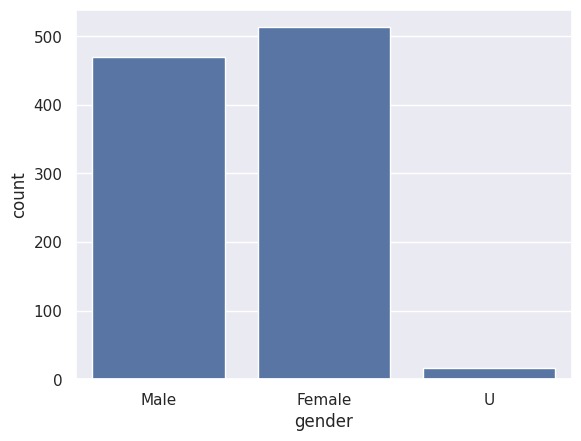

In [90]:
sns.countplot(data=df_clean, x='gender')

In [91]:
gender_mapping = {
    'Female': 'Female',
    'Male': 'Male',
    'U': 'Unknown'
}

df_clean['gender'] = df_clean['gender'].map(gender_mapping)

<Axes: xlabel='gender', ylabel='count'>

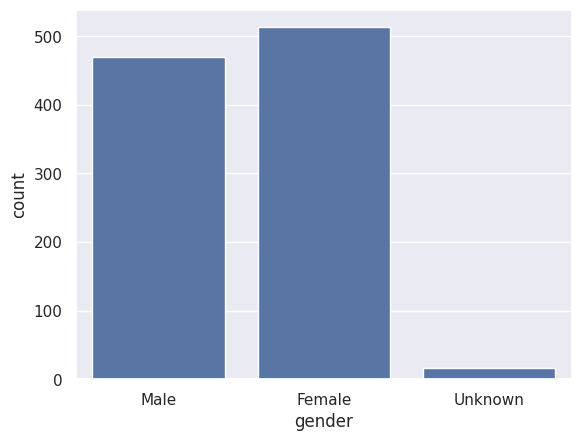

In [92]:
sns.countplot(data=df_clean, x='gender')

---

## Date of Birth

In [93]:
# Chuyển đổi DOB thành tuổi
current_year = datetime.now().year
df_clean['Age'] = df_clean['DOB'].apply(lambda x: current_year - int(x.split('-')[0]) if pd.notnull(x) else np.nan)

<Axes: xlabel='Age', ylabel='Count'>

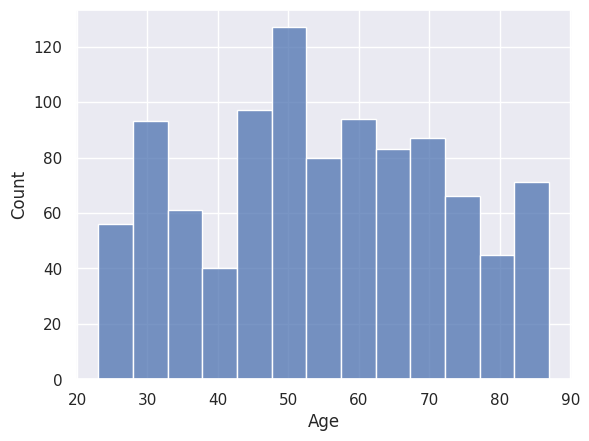

In [94]:
sns.histplot(data=df_clean, x='Age')

In [95]:
df_clean['Age'].describe()

,Age
count,1000.00
mean,54.71
std,17.36
min,23.00
25%,42.75
50%,54.00
75%,69.00
max,87.00


---

## Chuyển kiểu float

In [96]:
df_clean[['Value', 'property_valuation']].head(5)

,Value,property_valuation
0,"1,71875",6
1,"1,71875",11
2,"1,71875",5
3,"1,703125",1
4,"1,703125",9


In [97]:
# Chuyển sang kiểu chuỗi 100%
df_clean['Value'] = df_clean['Value'].astype(str)
df_clean['property_valuation'] = df_clean['property_valuation'].astype(str)

# loại bỏ khoảng trắng thừa
df_clean['Value'] = df_clean['Value'].str.strip()
df_clean['property_valuation'] = df_clean['property_valuation'].str.strip()

# Xử lý cột Value
df_clean['Value'] = df_clean['Value'].str.replace(',', '.').astype(float)  # Thay thế dấu phẩy và chuyển sang float

def convert_to_numeric(value):
    if ',' in value:
        return float(value.replace(',', '.'))
    else:
        return float(value)

# Áp dụng hàm convert_to_numeric cho cột 'property_valuation'
df_clean['property_valuation'] = df_clean['property_valuation'].apply(convert_to_numeric)

# Kiểm tra kết quả
print(df_clean[['Value', 'property_valuation']].dtypes)

Value                 float64
property_valuation    float64
dtype: object


In [98]:
df_clean[['Value', 'property_valuation']].describe()

,Value,property_valuation
count,1000.00,1000.00
mean,0.88,7.40
std,0.29,2.76
min,0.34,1.00
25%,0.65,6.00
50%,0.86,8.00
75%,1.07,9.00
max,1.72,12.00


----

## Xử lý dữ liệu bị thiếu với tỉ lệ lớn

In [99]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_industry_category,165
job_title,106


---
Dữ liệu không thiếu giá trị (train_data): Dùng để huấn luyện mô hình Random Forest.

Chọn ra những đặc trưng tốt nhất và suy đoán dựa trên đặc trưng đó

In [100]:
# Tạo dữ liệu train
def prepare_data_for_imputation(df, target_column, features):
    train_data = df[df[target_column].notna()]
    X_train = train_data[features]
    y_train = train_data[target_column]
    return X_train, y_train

---

### job_industry_category

In [101]:
# Xác định features and target
target_column = 'job_industry_category'

nominal_features = ['gender', 'deceased_indicator', 'owns_car', 'state']

ordianal_features = ['wealth_segment']

numerical_features = ['past_3_years_bike_related_purchases', 'tenure', 'property_valuation', 'Value', 'Age']

features = nominal_features + numerical_features + ordianal_features

In [102]:
X_train_job_ind, y_train_job_ind = prepare_data_for_imputation(df_clean, target_column = target_column, features = features)
print(f'X_train_job_ind: {X_train_job_ind.shape}')
print(f'y_train_job_ind: {y_train_job_ind.shape}')

X_train_job_ind: (835, 10)
y_train_job_ind: (835,)


In [103]:
# mapping for ordinal features
X_train_job_ind['wealth_segment'] = (
    X_train_job_ind['wealth_segment']
    .map({'High Net Worth': 2,
          'Affluent Customer': 1,
          'Mass Customer': 0})
)

In [104]:
# get dummies
X_train_job_ind = pd.get_dummies(X_train_job_ind, columns=nominal_features, drop_first=True)

In [105]:
# In ra kích thước của dữ liệu đã được chuyển đổi
print(f'X_train_job_ind_transformed: {X_train_job_ind.shape}')
print(f'y_train_job_ind: {y_train_job_ind.shape}')

X_train_job_ind_transformed: (835, 11)
y_train_job_ind: (835,)


In [106]:
# Train a Random Forest Model
rf_job_ind = RandomForestClassifier(n_estimators=100, random_state=42)
rf_job_ind.fit(X_train_job_ind, y_train_job_ind)

RandomForestClassifier(random_state=42)

In [107]:
# Get feature importance
importance = rf_job_ind.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train_job_ind.columns,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance from Random Forest")
importance_df

Feature Importance from Random Forest


,Feature,Importance
3,Value,0.18
4,Age,0.17
0,past_3_years_bike_related_purchases,0.17
1,tenure,0.15
2,property_valuation,0.13
5,wealth_segment,0.05
8,owns_car_Yes,0.04
6,gender_Male,0.04
10,state_VIC,0.03
9,state_QLD,0.03


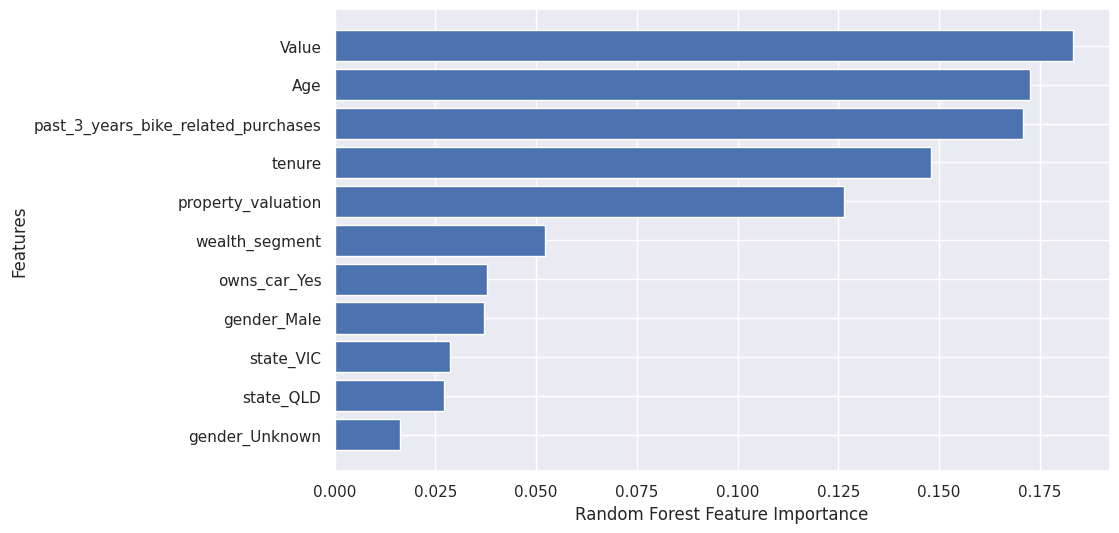

In [108]:
# Plot features importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.show()

In [109]:
# Nhóm theo nhiều cột
grouped_mode = df_clean.groupby(['past_3_years_bike_related_purchases'])['job_industry_category'].apply(lambda x: x.mode()[0])
grouped_mode

,job_industry_category
past_3_years_bike_related_purchases,
0,Health
1,Manufacturing
2,Financial Services
3,Financial Services
4,Financial Services
...,...
95,Health
96,Manufacturing
97,Financial Services


In [110]:
# Điền giá trị bị thiếu
df_clean['job_industry_category'] = df_clean['job_industry_category'].fillna(df_clean['past_3_years_bike_related_purchases'].map(grouped_mode))

In [111]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0
job_title,106


In [112]:
origin_df = df['job_industry_category'].value_counts()
new_df = df_clean['job_industry_category'].value_counts()

# Nối 2 bảng
df_compare = pd.concat([origin_df, new_df], axis=1)
df_compare.columns = ['Origin', 'New']
df_compare

,Origin,New
job_industry_category,,
Financial Services,203,271
Manufacturing,199,240
Health,152,191
Retail,78,79
Property,64,64
IT,51,57
Entertainment,37,41
Argiculture,26,32
Telecommunications,25,25


---
---

### job_title

In [113]:
# Xác định features and target
target_column = 'job_title'

nominal_features = ['gender', 'deceased_indicator', 'owns_car', 'state', 'job_industry_category']

ordianal_features = ['wealth_segment']

numerical_features = ['past_3_years_bike_related_purchases', 'tenure', 'property_valuation', 'Value', 'Age']

features = nominal_features + numerical_features + ordianal_features

In [114]:
X_train_job_title, y_train_job_title = prepare_data_for_imputation(df_clean, target_column = target_column, features = features)
print(f'X_train_job_title: {X_train_job_title.shape}')
print(f'y_train_job_title: {y_train_job_title.shape}')

X_train_job_title: (894, 11)
y_train_job_title: (894,)


In [115]:
# mapping
X_train_job_title['wealth_segment'] = (
    X_train_job_title['wealth_segment']
    .map({'High Net Worth': 2,
          'Affluent Customer': 1,
          'Mass Customer': 0}))

In [116]:
# get dummies
X_train_job_title = pd.get_dummies(X_train_job_title, columns=nominal_features, drop_first=True)

In [117]:
# in ra kích thước đã chuyển đổi
print(f'X_train_job_title_transformed: {X_train_job_title.shape}')
print(f'y_train_job_title: {y_train_job_title.shape}')

X_train_job_title_transformed: (894, 19)
y_train_job_title: (894,)


In [118]:
# Train a Random Forest Model
rf_job_title = RandomForestClassifier(n_estimators=100, random_state=42)
rf_job_title.fit(X_train_job_title, y_train_job_title)

RandomForestClassifier(random_state=42)

In [119]:
# Get feature importance
importance = rf_job_title.feature_importances_
importance_df = pd.DataFrame({
    'Feature': X_train_job_title.columns,
    'Importance': importance
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance from Random Forest")
importance_df

Feature Importance from Random Forest


,Feature,Importance
3,Value,0.16
0,past_3_years_bike_related_purchases,0.15
4,Age,0.15
1,tenure,0.14
2,property_valuation,0.12
5,wealth_segment,0.06
8,owns_car_Yes,0.04
6,gender_Male,0.04
10,state_VIC,0.04
9,state_QLD,0.03


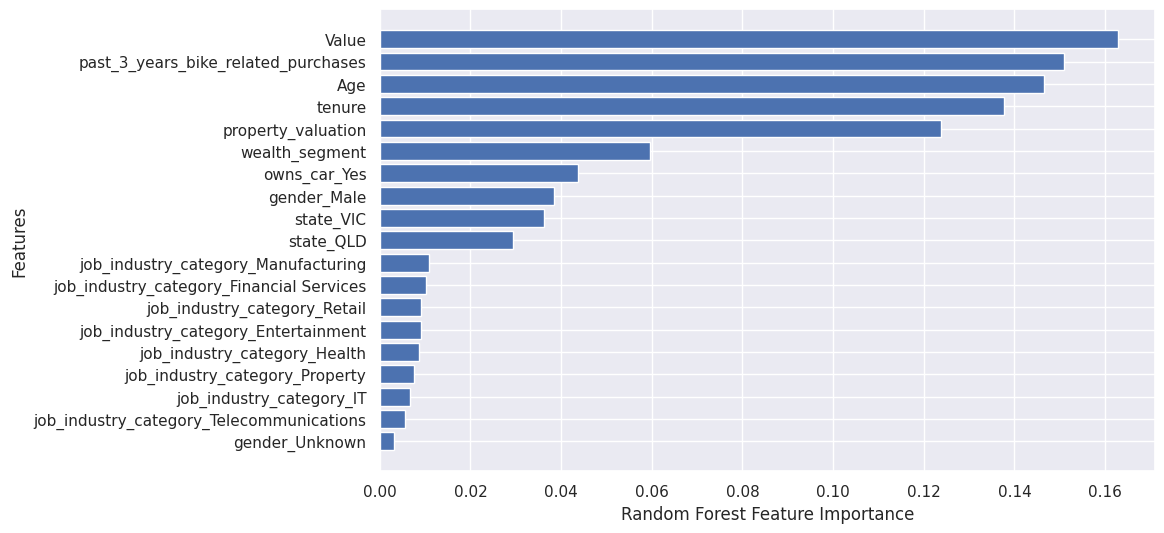

In [120]:
# Plot features importance
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.show()

In [121]:
# Nhóm theo nhiều cột
grouped_mode = df_clean.groupby(['past_3_years_bike_related_purchases'])['job_title'].apply(lambda x: x.mode()[0])
grouped_mode

,job_title
past_3_years_bike_related_purchases,
0,Accountant III
1,Accounting Assistant I
2,Automation Specialist II
3,Payment Adjustment Coordinator
4,VP Product Management
...,...
95,Cost Accountant
96,Account Representative III
97,Chemical Engineer


In [122]:
# Điền giá trị bị thiếu
df_clean['job_title'] = df_clean['job_title'].fillna(df_clean['past_3_years_bike_related_purchases'].map(grouped_mode))

In [123]:
# check missing value
missing = df_clean.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing

,0


In [124]:
origin_df = df['job_title'].value_counts()
new_df = df_clean['job_title'].value_counts()

# nối 2 bảng
df_compare = pd.concat([origin_df, new_df], axis=1)
df_compare.columns = ['Origin', 'New']
df_compare = df_compare[df_compare['Origin'] != df_compare['New']]
df_compare

,Origin,New
job_title,,
Associate Professor,15,21
Environmental Tech,14,15
Chief Design Engineer,13,15
Assistant Manager,12,20
Assistant Media Planner,12,14
Senior Sales Associate,12,14
Cost Accountant,12,14
Account Executive,11,16
Business Systems Development Analyst,10,13


---

## Kiểm tra hàng bị trùng lặp

In [125]:
# Kiểm tra dữ liệu trùng lặp
duplicate_rows = df_clean.duplicated()
print("\nSố lượng bản ghi trùng lặp:", duplicate_rows.sum())

# Nếu có bản ghi trùng lặp, loại bỏ chúng
if duplicate_rows.sum() > 0:
    data_cleaned = df_clean.drop_duplicates()
    print("Đã loại bỏ các bản ghi trùng lặp.")


Số lượng bản ghi trùng lặp: 0


# So sánh data clean và data gốc

In [126]:
percentage = len(df_clean) / len(df) * 100
print(f'Data clean chiếm  {percentage:.2f}% so với data gốc')

Data clean chiếm  100.00% so với data gốc


# Sắp xếp lại các cột

In [127]:
print(f'Số cột của data gốc: {len(df.columns)}')
print(f'Số cột của data clean: {len(df_clean.columns)}')

Số cột của data gốc: 23
Số cột của data clean: 18


In [128]:
# Lấy danh sách các cột kiểu object
object_columns = df_clean.select_dtypes(include=['object']).columns.tolist()

# Lấy danh sách các cột kiểu numeric
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Sắp xếp lại thứ tự cột: Numeric -> Object
df_clean = df_clean[numeric_columns + object_columns]

# Kiểm tra số cột
print(f'Số cột của data clean sau khi sắp xếp cột : {len(df_clean.columns)}')

Số cột của data clean sau khi sắp xếp cột : 18


# Lưu data đã được làm sạch

In [129]:
df_clean.to_csv('Cleaned_NewCustomerList.csv', index=False)